In [1]:
# Install required packages
!pip install kagglehub torch torchvision Pillow matplotlib tqdm -q

In [2]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import random
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.64 GB


In [3]:
# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

image_dir = os.path.join(dataset_path, "images")
annotation_dir = os.path.join(dataset_path, "annotations")

print(f"Dataset path: {dataset_path}")
print(f"Images:      {len(os.listdir(image_dir))}")
print(f"Annotations: {len(os.listdir(annotation_dir))}")

100%|██████████| 398M/398M [00:13<00:00, 31.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1
Images:      853
Annotations: 853


In [4]:
# Label mapping (matches app.py)
# Background = 0 (Faster R-CNN convention)
LABEL_MAP = {
    'with_mask': 1,
    'without_mask': 2,
    'mask_weared_incorrect': 3
}
NUM_CLASSES = 4  # 3 classes + background


class FaceMaskDataset(Dataset):
    """
    Pascal VOC-style XML annotation dataset for face mask detection.
    """

    def __init__(self, image_dir, annotation_dir, transforms=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.transforms = transforms

        # Only keep images that have a matching annotation
        self.samples = []
        for ann_file in sorted(os.listdir(annotation_dir)):
            if not ann_file.endswith('.xml'):
                continue
            stem = os.path.splitext(ann_file)[0]
            # Try both .png and .jpg
            for ext in ('.png', '.jpg', '.jpeg'):
                img_path = os.path.join(image_dir, stem + ext)
                if os.path.exists(img_path):
                    self.samples.append((img_path, os.path.join(annotation_dir, ann_file)))
                    break

        print(f"Loaded {len(self.samples)} valid image-annotation pairs")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path = self.samples[idx]

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Parse XML annotation
        boxes, labels = self._parse_annotation(ann_path)

        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        if self.transforms:
            image = self.transforms(image)
        else:
            image = T.ToTensor()(image)

        return image, target

    def _parse_annotation(self, ann_path):
        tree = ET.parse(ann_path)
        root = tree.getroot()
        boxes, labels = [], []

        for obj in root.findall('object'):
            name = obj.find('name').text.strip()
            label = LABEL_MAP.get(name)
            if label is None:
                continue  # skip unknown classes

            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)

            # Guard: ensure valid box
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        # Fallback: if empty annotation return dummy (will be filtered by collate)
        if len(boxes) == 0:
            boxes = [[0, 0, 1, 1]]
            labels = [0]  # background

        return boxes, labels


def collate_fn(batch):
    return tuple(zip(*batch))


print("Dataset class defined ✓")

Dataset class defined ✓


In [5]:
# Training transforms: ColorJitter + RandomGrayscale (bounding box-safe)
# Note: Faster R-CNN internally handles flipping — we apply only pixel-level augmentation here
train_transforms = T.Compose([
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
])

val_transforms = T.Compose([
    T.ToTensor(),
])

print("Transforms defined ✓")

Transforms defined ✓


In [6]:
BATCH_SIZE = 4      # Reduce to 2 if you get OOM errors
NUM_WORKERS = 2
VAL_SPLIT = 0.1     # 90% train / 10% val

full_dataset = FaceMaskDataset(image_dir, annotation_dir)

n_val = int(len(full_dataset) * VAL_SPLIT)
n_train = len(full_dataset) - n_val

train_dataset, val_dataset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Assign transforms AFTER split (hack: monkey-patch the subset)
train_dataset.dataset.transforms = train_transforms
# For val we use a copy-like approach — override via wrapper
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transforms):
        self.subset = subset
        self.transforms = transforms
        self.subset.dataset.transforms = None  # disable dataset-level

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path, ann_path = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(img_path).convert('RGB')
        boxes, labels = self.subset.dataset._parse_annotation(ann_path)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {'boxes': boxes, 'labels': labels, 'image_id': torch.tensor([idx])}
        image = self.transforms(image)
        return image, target

val_dataset_wrapped = SubsetWithTransform(val_dataset, val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset_wrapped, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True
)

print(f"Train samples: {n_train}")
print(f"Val   samples: {n_val}")
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Loaded 853 valid image-annotation pairs
Train samples: 768
Val   samples: 85
Train batches: 192
Val   batches: 22


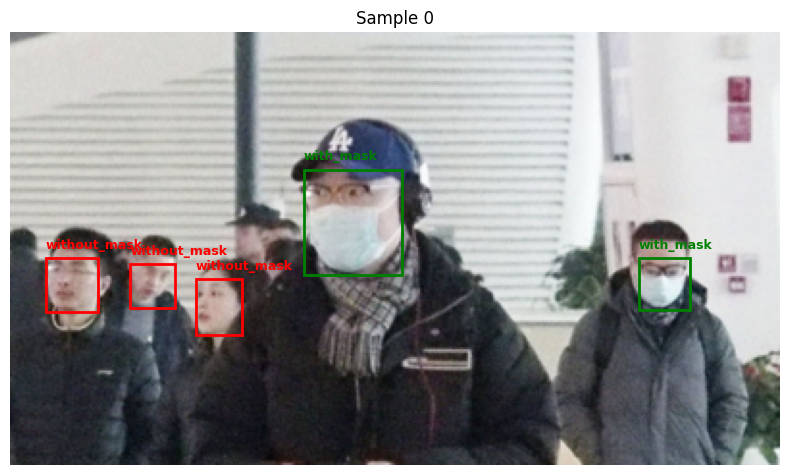

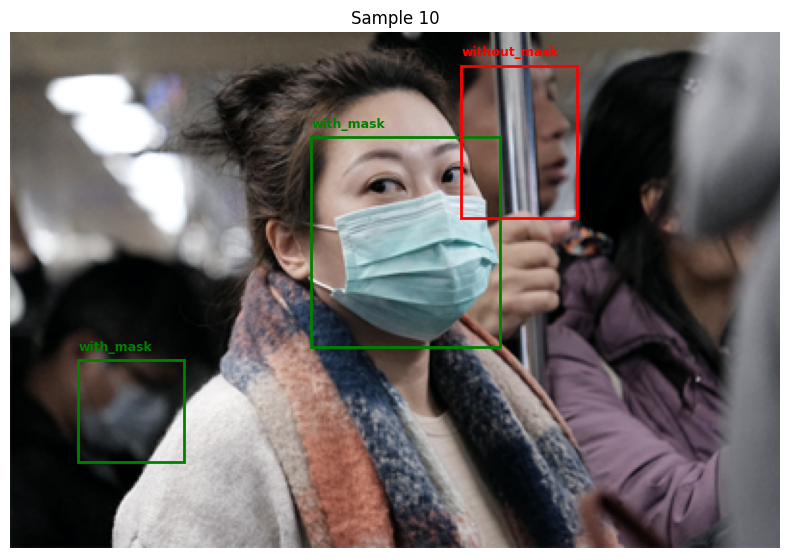

In [7]:
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
COLORS = {1: 'green', 2: 'red', 3: 'orange'}

def visualize_sample(dataset, idx=0):
    image, target = dataset[idx]
    if isinstance(image, torch.Tensor):
        img_np = image.permute(1, 2, 0).numpy()
    else:
        img_np = np.array(image)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img_np)
    for box, label in zip(target['boxes'], target['labels']):
        x1, y1, x2, y2 = box.tolist()
        label_id = label.item()
        color = COLORS.get(label_id, 'blue')
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, INV_LABEL_MAP.get(label_id, 'unknown'),
                color=color, fontsize=9, weight='bold')
    plt.title(f'Sample {idx}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample(train_dataset, idx=0)
visualize_sample(train_dataset, idx=10)

In [8]:
def build_model(num_classes, pretrained=True):
    """
    Faster R-CNN ResNet50 FPN with COCO pretrained backbone.
    Fine-tune the box predictor head for num_classes.
    """
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
    model = fasterrcnn_resnet50_fpn(weights=weights)

    # Replace the box predictor head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_model(NUM_CLASSES, pretrained=True)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 161MB/s]


Total parameters:     41,309,411
Trainable parameters: 41,087,011


In [9]:
# ── Phase 1: Train only the head (first 5 epochs) ──────────────────────────
# Freeze backbone
for name, param in model.named_parameters():
    if 'box_predictor' not in name:
        param.requires_grad = False

# ── Phase 2: Full fine-tune (unfreeze all after warmup) ────────────────────
# We handle this inside the training loop

def get_optimizer(model, lr=0.005):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params, lr=lr,
        momentum=0.9,
        weight_decay=5e-4,
        nesterov=True
    )
    return optimizer


NUM_EPOCHS = 20          # total epochs
WARMUP_EPOCHS = 3        # head-only warmup
LR_HEAD = 0.01           # learning rate for warmup
LR_FULL = 0.005          # learning rate for full fine-tune

optimizer = get_optimizer(model, lr=LR_HEAD)

# Cosine annealing after warmup
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=(NUM_EPOCHS - WARMUP_EPOCHS), eta_min=1e-5
)

print(f"Optimizer: SGD (momentum=0.9, nesterov=True, wd=5e-4)")
print(f"Scheduler: CosineAnnealing (T_max={NUM_EPOCHS - WARMUP_EPOCHS})")

Optimizer: SGD (momentum=0.9, nesterov=True, wd=5e-4)
Scheduler: CosineAnnealing (T_max=17)


In [10]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=torch.cuda.is_available())


def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(data_loader, desc=f"Epoch {epoch+1} [TRAIN]")

    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with autocast(enabled=torch.cuda.is_available()):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(data_loader)
    return avg_loss


@torch.no_grad()
def evaluate(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    """
    Computes per-class detection accuracy:
      - True positive: predicted box with IoU >= threshold AND correct label
      - Reports overall detection accuracy across all GT boxes.
    """
    model.eval()
    total_gt = 0
    total_tp = 0

    for images, targets in tqdm(data_loader, desc="  [VAL]", leave=False):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for target, output in zip(targets, outputs):
            gt_boxes = target['boxes']
            gt_labels = target['labels']

            pred_boxes = output['boxes'].cpu()
            pred_labels = output['labels'].cpu()
            pred_scores = output['scores'].cpu()

            # Keep only high-confidence predictions
            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            matched = set()
            for gt_box, gt_label in zip(gt_boxes, gt_labels):
                if gt_label.item() == 0:
                    continue  # skip background dummies
                total_gt += 1

                if len(pred_boxes) == 0:
                    continue

                ious = box_iou(gt_box.unsqueeze(0), pred_boxes)[0]
                best_idx = ious.argmax().item()
                best_iou = ious[best_idx].item()

                if (
                    best_iou >= iou_threshold
                    and pred_labels[best_idx].item() == gt_label.item()
                    and best_idx not in matched
                ):
                    total_tp += 1
                    matched.add(best_idx)

    accuracy = total_tp / total_gt if total_gt > 0 else 0.0
    return accuracy, total_tp, total_gt


def box_iou(box1, box2):
    """Compute IoU between one box and many boxes."""
    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])

    inter_x1 = torch.max(box1[:, 0].unsqueeze(1), box2[:, 0].unsqueeze(0))
    inter_y1 = torch.max(box1[:, 1].unsqueeze(1), box2[:, 1].unsqueeze(0))
    inter_x2 = torch.min(box1[:, 2].unsqueeze(1), box2[:, 2].unsqueeze(0))
    inter_y2 = torch.min(box1[:, 3].unsqueeze(1), box2[:, 3].unsqueeze(0))

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    union_area = area1.unsqueeze(1) + area2.unsqueeze(0) - inter_area
    return inter_area / union_area.clamp(min=1e-6)


print("Training utilities defined ✓")

Training utilities defined ✓


In [11]:
SAVE_PATH = 'mask_detector High acccu.pth'   # matches app.py exactly
best_accuracy = 0.0
history = {'train_loss': [], 'val_accuracy': [], 'lr': []}

print("=" * 60)
print(f"Training for {NUM_EPOCHS} epochs on {device}")
print(f"  Warmup (head-only) : epochs 1-{WARMUP_EPOCHS}  LR={LR_HEAD}")
print(f"  Full fine-tune     : epochs {WARMUP_EPOCHS+1}-{NUM_EPOCHS}  LR={LR_FULL}")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    # ── Phase switch: unfreeze backbone after warmup ──────────────────────
    if epoch == WARMUP_EPOCHS:
        print(f"\n>>> Epoch {epoch+1}: Unfreezing full backbone for fine-tuning...")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = get_optimizer(model, lr=LR_FULL)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(NUM_EPOCHS - WARMUP_EPOCHS), eta_min=1e-5
        )

    # ── Train ─────────────────────────────────────────────────────────────
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)

    # ── Validate ──────────────────────────────────────────────────────────
    val_acc, tp, gt = evaluate(model, val_loader, device)

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_accuracy'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Loss: {train_loss:.4f}  "
          f"Val Acc: {val_acc*100:.2f}%  "
          f"TP/GT: {tp}/{gt}  "
          f"LR: {current_lr:.6f}")

    # ── Save best model ───────────────────────────────────────────────────
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ New best model saved! Accuracy: {val_acc*100:.2f}%")

    # Step scheduler only during full fine-tune phase
    if epoch >= WARMUP_EPOCHS:
        scheduler.step()

print("\n" + "=" * 60)
print(f"Training complete. Best Val Accuracy: {best_accuracy*100:.2f}%")
print(f"Model saved to: {SAVE_PATH}")
print("=" * 60)

Training for 20 epochs on cuda
  Warmup (head-only) : epochs 1-3  LR=0.01
  Full fine-tune     : epochs 4-20  LR=0.005


Epoch 1 [TRAIN]: 100%|██████████| 192/192 [01:17<00:00,  2.48it/s, loss=0.6578]


Epoch [01/20] Loss: 0.4448  Val Acc: 40.97%  TP/GT: 143/349  LR: 0.010000
  ✅ New best model saved! Accuracy: 40.97%


Epoch 2 [TRAIN]: 100%|██████████| 192/192 [01:15<00:00,  2.55it/s, loss=0.6475]


Epoch [02/20] Loss: 0.3914  Val Acc: 42.41%  TP/GT: 148/349  LR: 0.010000
  ✅ New best model saved! Accuracy: 42.41%


...

Epoch [18/20] Loss: 0.0621  Val Acc: 93.70%  TP/GT: 327/349  LR: 0.000384


Epoch 19 [TRAIN]: 100%|██████████| 192/192 [02:55<00:00,  1.09it/s, loss=0.0493]


Epoch [19/20] Loss: 0.0601  Val Acc: 94.56%  TP/GT: 330/349  LR: 0.000178


Epoch 20 [TRAIN]: 100%|██████████| 192/192 [02:57<00:00,  1.08it/s, loss=0.1426]
                                                        

Epoch [20/20] Loss: 0.0592  Val Acc: 93.70%  TP/GT: 327/349  LR: 0.000052

Training complete. Best Val Accuracy: 95.99%
Model saved to: mask_detector High acccu.pth


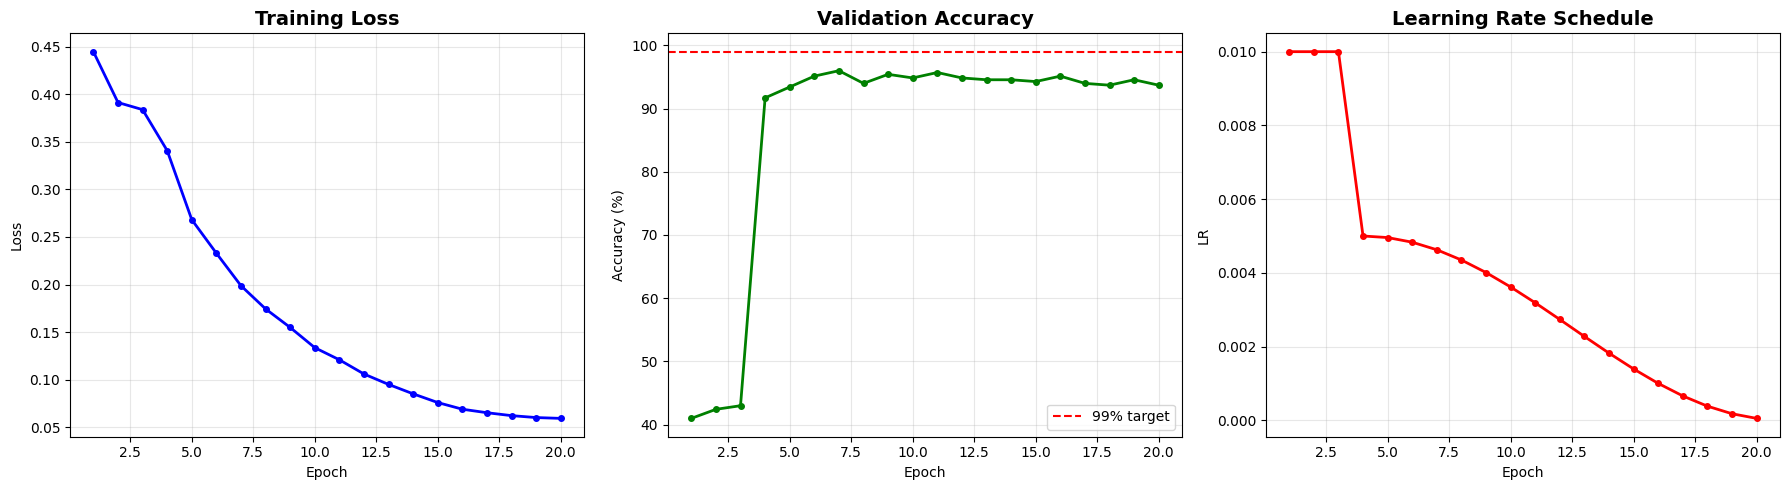

Best accuracy achieved: 95.99%


In [12]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', linewidth=2, markersize=4)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history['val_accuracy']], 'g-o', linewidth=2, markersize=4)
axes[1].axhline(y=99, color='red', linestyle='--', label='99% target')
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['lr'], 'r-o', linewidth=2, markersize=4)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best accuracy achieved: {best_accuracy*100:.2f}%")

In [13]:
# Load best model for final eval
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.to(device)
model.eval()

# Evaluate at different IoU thresholds
print("Final evaluation with best model:")
print("-" * 40)
for iou_t in [0.4, 0.5, 0.6]:
    acc, tp, gt = evaluate(model, val_loader, device, iou_threshold=iou_t, score_threshold=0.5)
    print(f"IoU@{iou_t:.1f} | Accuracy: {acc*100:.2f}%  TP={tp} GT={gt}")
print("-" * 40)

Final evaluation with best model:
----------------------------------------


IoU@0.4 | Accuracy: 96.56%  TP=337 GT=349


IoU@0.5 | Accuracy: 95.99%  TP=335 GT=349


IoU@0.6 | Accuracy: 95.13%  TP=332 GT=349
----------------------------------------


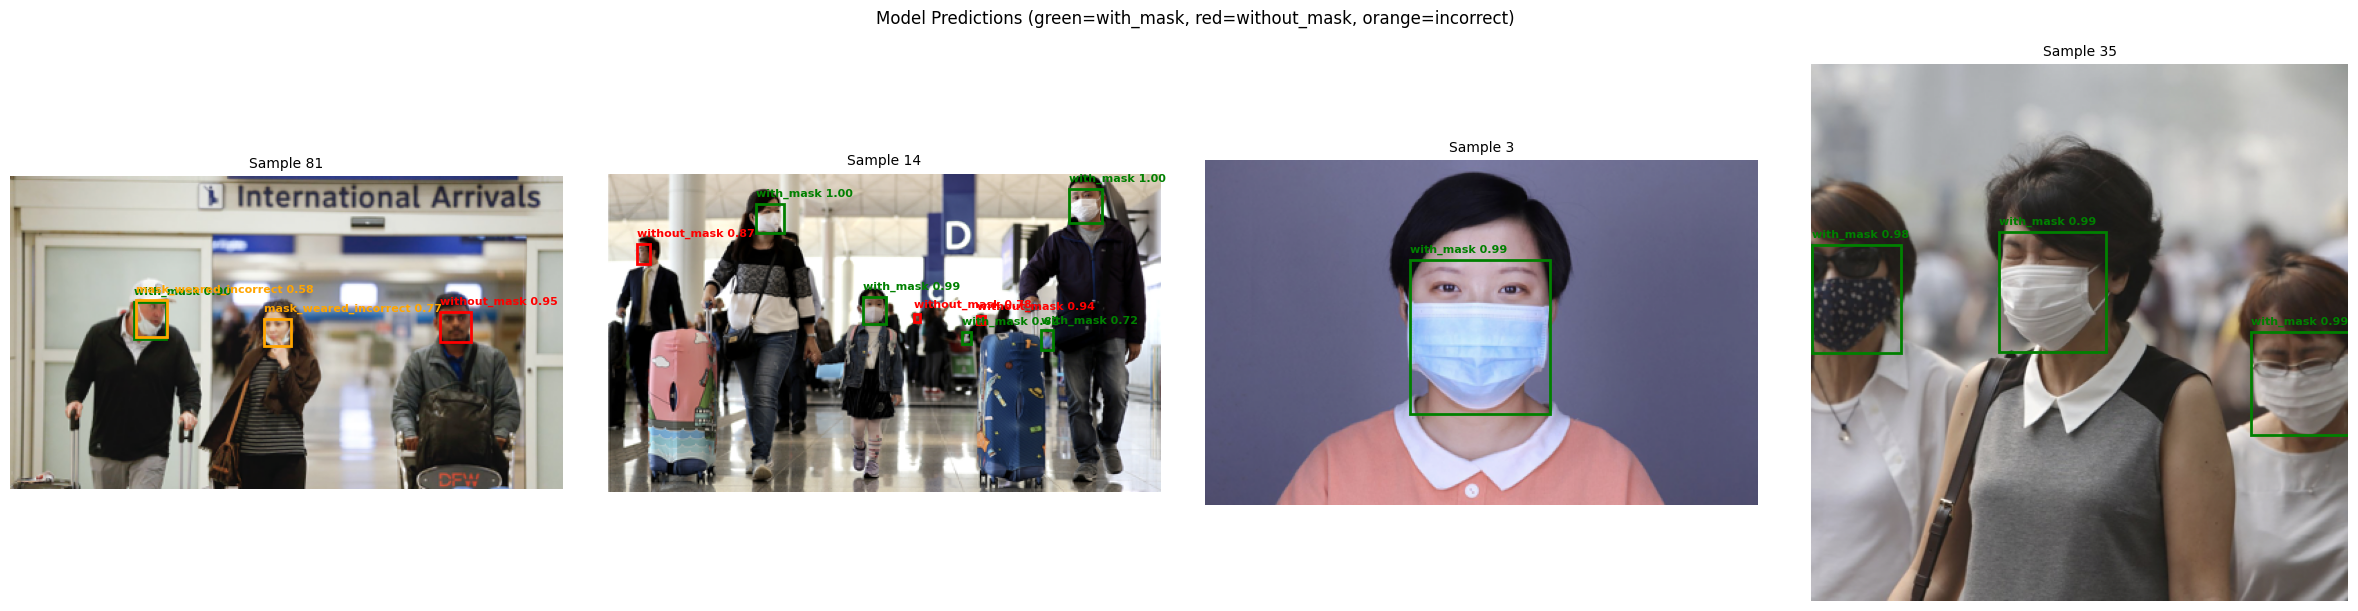

In [14]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, indices=None, score_threshold=0.5):
    model.eval()
    if indices is None:
        indices = random.sample(range(len(dataset)), min(4, len(dataset)))

    fig, axes = plt.subplots(1, len(indices), figsize=(6 * len(indices), 6))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        img_tensor = image.unsqueeze(0).to(device)
        outputs = model(img_tensor)[0]

        img_np = image.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Draw predictions
        for box, label, score in zip(
            outputs['boxes'].cpu(),
            outputs['labels'].cpu(),
            outputs['scores'].cpu()
        ):
            if score < score_threshold:
                continue
            x1, y1, x2, y2 = box.tolist()
            color = COLORS.get(label.item(), 'blue')
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5,
                    f"{INV_LABEL_MAP.get(label.item(), '?')} {score:.2f}",
                    color=color, fontsize=8, weight='bold')

        ax.set_title(f'Sample {idx}', fontsize=10)
        ax.axis('off')

    plt.suptitle('Model Predictions (green=with_mask, red=without_mask, orange=incorrect)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('predictions_sample.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(model, val_dataset_wrapped, device)

In [15]:
# In Google Colab: download the model file
try:
    from google.colab import files
    print(f"Downloading model: {SAVE_PATH}")
    files.download(SAVE_PATH)
    print("Download started!")
except ImportError:
    print(f"Model saved at: {os.path.abspath(SAVE_PATH)}")
    print("Copy this file to use with app.py")

# Verify file size
size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f"Model file size: {size_mb:.1f} MB")
print(f"\n✅ Done! Place '{SAVE_PATH}' in the same directory as app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
Model file size: 165.8 MB

✅ Done! Place 'mask_detector High acccu.pth' in the same directory as app.py
